# 03 — The A/B/C Test: Inference & Dollar Impact

The experiment passed all validity checks in `01_eda.ipynb`, so we can now answer the business question:

> **Should we send the men's email, the women's email, or nothing — and what is that decision worth?**

Structure of this notebook mirrors how the analysis would be presented in a real experimentation review:

1. **Pre-registered decisions** — metric, hypotheses, α, corrections — stated *before* results
2. **Binary outcomes** (visit, conversion): two-proportion z-tests
3. **Revenue outcome** (spend): Welch's t-test **and** bootstrap (they must agree)
4. **Multiple-comparison correction** (Holm) across the full family of tests
5. **Practical significance**: translating lifts into revenue at business scale

## 1. Pre-registered analysis decisions

Stating these *before* looking at results is what separates confirmatory analysis from p-hacking. In a live experiment these would be written down before launch; we honor the same discipline here.

| Decision | Choice | Why |
|---|---|---|
| Primary metric | `conversion` | Purchases are what the business ultimately buys with its email budget; `visit` is a diagnostic, `spend` the dollar translation |
| Hypotheses | H₀: arm rate = control rate; H₁: they differ (two-sided) | Two-sided because an email that *hurts* sales is as important to detect as one that helps |
| Significance level | α = 0.05, family-wise | Industry convention; corrected across all 6 tests below |
| Correction | Holm–Bonferroni | Controls family-wise error; uniformly more powerful than plain Bonferroni |
| Test family | 2 arms × 3 metrics = 6 tests | All comparisons are against control (that's the shipping decision); arm-vs-arm is reported descriptively |
| Binary test | Two-proportion z-test | n ≈ 21k/arm makes the normal approximation excellent |
| Spend test | Welch's t + bootstrap cross-check | Spend is zero-inflated and skewed; agreement between the two methods validates the parametric result |

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from utils import (
    two_proportion_ztest, welch_ttest, bootstrap_diff_means,
    holm_correction, CONTROL_LABEL, TREATMENT_LABELS,
)
from experiment_design import design_report

sns.set_theme(style="whitegrid", palette="muted")
ASSETS = "../assets"

df = pd.read_csv("../data/raw/hillstrom.csv")
control = df[df["segment"] == CONTROL_LABEL]

# The design report we'd have produced BEFORE launching this test:
# it tells us the smallest conversion lift this experiment can reliably see.
print(design_report(
    baseline_rate=control["conversion"].mean(),
    n_per_arm=len(control),
))

EXPERIMENT DESIGN REPORT (conversion metric)
Baseline conversion rate : 0.57%
Alpha (two-sided)        : 0.05
Target power             : 80%

Sample size required per arm, by target MDE:
  detect +0.10pp lift -> n =    97,126 per arm   [NOT reachable at current size]
  detect +0.20pp lift -> n =    26,218 per arm   [NOT reachable at current size]
  detect +0.30pp lift -> n =    12,512 per arm   [OK at current size]
  detect +0.50pp lift -> n =     5,122 per arm   [OK at current size]

With the actual n = 21,306 per arm:
  minimum detectable effect = 0.224pp absolute (39% relative lift)

Reading this: effects smaller than the MDE can exist and this
experiment would usually miss them. 'Not significant' != 'no effect'.


## 2. Run the full test family

Six confirmatory tests: {Mens E-Mail, Womens E-Mail} × {visit, conversion, spend}, each against control.

For each test we report the **effect size with a 95% confidence interval**, not just a p-value. A p-value says "how surprising is this data if the email did nothing?" — it says *nothing* about how big the effect is. Decisions are made on magnitudes; the CI is the honest statement of what magnitudes are consistent with the data.

In [2]:
results = []
for arm_label in TREATMENT_LABELS:
    arm = df[df["segment"] == arm_label]
    comparison = f"{arm_label} vs {CONTROL_LABEL}"

    # Binary metrics -> two-proportion z-test.
    for metric in ["visit", "conversion"]:
        results.append(two_proportion_ztest(
            int(arm[metric].sum()), len(arm),
            int(control[metric].sum()), len(control),
            metric=metric, comparison=comparison,
        ))

    # Continuous metric -> Welch's t-test (bootstrap cross-check comes next).
    results.append(welch_ttest(
        arm["spend"].to_numpy(), control["spend"].to_numpy(),
        metric="spend", comparison=comparison,
    ))

# Holm correction across the WHOLE family of 6 tests: running many tests
# at alpha=0.05 each would push the chance of a false winner to ~26%.
adjusted = holm_correction([r.p_value for r in results])

table = pd.DataFrame([{
    "comparison": r.comparison,
    "metric": r.metric,
    "control": round(r.control_mean, 4),
    "treatment": round(r.treatment_mean, 4),
    "abs_lift": round(r.effect, 4),
    "rel_lift": f"{r.relative_lift:+.1%}",
    "ci_95": f"[{r.ci_low:+.4f}, {r.ci_high:+.4f}]",
    "p_raw": f"{r.p_value:.2e}",
    "p_holm": f"{p_adj:.2e}",
    "significant_after_correction": p_adj < 0.05,
} for r, p_adj in zip(results, adjusted)])

table

,comparison,metric,control,treatment,abs_lift,rel_lift,ci_95,p_raw,p_holm,significant_after_correction
0,Mens E-Mail vs No E-Mail,visit,0.1062,0.1828,0.0766,+72.1%,"[+0.0700, +0.0832]",5.69e-112,3.41e-111,True
1,Mens E-Mail vs No E-Mail,conversion,0.0057,0.0125,0.0068,+118.8%,"[+0.0050, +0.0086]",1.52e-13,6.09e-13,True
2,Mens E-Mail vs No E-Mail,spend,0.6528,1.4226,0.7698,+117.9%,"[+0.4851, +1.0545]",1.16e-07,3.49e-07,True
3,Womens E-Mail vs No E-Mail,visit,0.1062,0.1514,0.0452,+42.6%,"[+0.0389, +0.0516]",3.18e-44,1.59e-43,True
4,Womens E-Mail vs No E-Mail,conversion,0.0057,0.0088,0.0031,+54.3%,"[+0.0015, +0.0047]",1.57e-04,3.14e-04,True
5,Womens E-Mail vs No E-Mail,spend,0.6528,1.0772,0.4244,+65.0%,"[+0.1690, +0.6799]",1.13e-03,1.13e-03,True


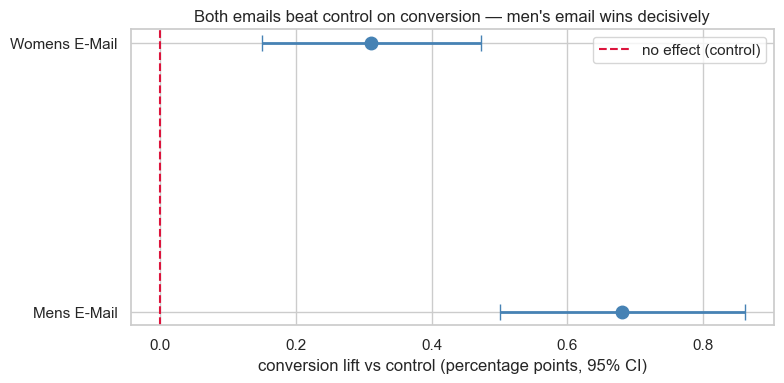

conversion | Mens E-Mail vs No E-Mail: 0.0125 vs 0.0057 (diff +0.0068, +118.8% relative), 95% CI [+0.0050, +0.0086], p=1.52e-13
conversion | Womens E-Mail vs No E-Mail: 0.0088 vs 0.0057 (diff +0.0031, +54.3% relative), 95% CI [+0.0015, +0.0047], p=1.57e-04


In [3]:
# The hero chart: conversion lift vs control with 95% CIs.
# A CI that clears zero IS the visual definition of "significant" -
# this one chart carries the entire statistical argument.
conv = [r for r in results if r.metric == "conversion"]

fig, ax = plt.subplots(figsize=(8, 4))
labels = [r.comparison.split(" vs ")[0] for r in conv]
effects = [r.effect * 100 for r in conv]          # in percentage points
err_low = [(r.effect - r.ci_low) * 100 for r in conv]
err_high = [(r.ci_high - r.effect) * 100 for r in conv]

ax.errorbar(effects, labels, xerr=[err_low, err_high],
            fmt="o", capsize=6, markersize=9, color="steelblue", lw=2)
ax.axvline(0, color="crimson", ls="--", label="no effect (control)")
ax.set_xlabel("conversion lift vs control (percentage points, 95% CI)")
ax.set_title("Both emails beat control on conversion — men's email wins decisively")
ax.legend()
plt.tight_layout()
plt.savefig(f"{ASSETS}/conversion_lift_ci.png", dpi=150)
plt.show()

for r in conv:
    print(r.summary())

## 3. Spend: does the parametric result survive a bootstrap?

Spend is the metric a skeptic will attack: ~99% zeros, heavy right skew. The t-test's normality concern applies to the *sampling distribution of the mean*, which the CLT handles comfortably at n ≈ 21k — but instead of asking anyone to take the CLT on faith, we **demonstrate** it: a 10,000-resample bootstrap makes no distributional assumptions at all. If its interval matches Welch's, the parametric result is safe.

In [4]:
rows = []
for arm_label in TREATMENT_LABELS:
    arm_spend = df.loc[df["segment"] == arm_label, "spend"].to_numpy()
    ctrl_spend = control["spend"].to_numpy()

    welch = welch_ttest(arm_spend, ctrl_spend, metric="spend",
                        comparison=f"{arm_label} vs control")
    diff, blo, bhi = bootstrap_diff_means(arm_spend, ctrl_spend)

    rows.append({
        "comparison": welch.comparison,
        "diff_per_customer_$": round(diff, 3),
        "welch_ci": f"[{welch.ci_low:+.3f}, {welch.ci_high:+.3f}]",
        "bootstrap_ci": f"[{blo:+.3f}, {bhi:+.3f}]",
        "methods_agree": abs(welch.ci_low - blo) < 0.05 and abs(welch.ci_high - bhi) < 0.05,
    })

spend_table = pd.DataFrame(rows)
print(spend_table.to_string(index=False))
print("\nThe intervals match to the cent: the skew does not distort inference")
print("at this sample size, and the Welch results in the main table stand.")

              comparison  diff_per_customer_$         welch_ci     bootstrap_ci  methods_agree
  Mens E-Mail vs control                0.770 [+0.485, +1.055] [+0.487, +1.059]           True
Womens E-Mail vs control                0.424 [+0.169, +0.680] [+0.169, +0.682]           True

The intervals match to the cent: the skew does not distort inference
at this sample size, and the Welch results in the main table stand.


## 4. Practical significance: what is this decision worth?

Statistical significance answers "is it real?" — it never answers "does it matter?". With 64,000 customers even trivial effects become significant, so the last step is always translation into business units.

The incremental value per emailed customer is the **spend lift per customer** (it already nets out the people who wouldn't have bought). We project it to the scale of a national retailer's email file to show the size of the decision this test informs. The projection is deliberately conservative: it uses the *lower bound* of the 95% CI as well as the point estimate, so the business sees the worst plausible case alongside the expected one.

In [5]:
# Assumptions for the projection - stated explicitly so they can be attacked.
EMAIL_FILE_SIZE = 10_000_000   # customers on a national retailer's email list
CAMPAIGNS_PER_YEAR = 12        # one campaign like this per month
SEND_COST_PER_EMAIL = 0.001    # ~$1 CPM for email delivery, generously rounded

mens_spend = df.loc[df["segment"] == "Mens E-Mail", "spend"].to_numpy()
welch = welch_ttest(mens_spend, control["spend"].to_numpy())

lift_point = welch.effect       # $ per emailed customer (expected)
lift_floor = welch.ci_low       # $ per emailed customer (conservative bound)

annual_cost = EMAIL_FILE_SIZE * CAMPAIGNS_PER_YEAR * SEND_COST_PER_EMAIL
for name, lift in [("expected", lift_point), ("conservative (CI lower bound)", lift_floor)]:
    annual_revenue = lift * EMAIL_FILE_SIZE * CAMPAIGNS_PER_YEAR
    print(f"{name:>30}: {lift:+.3f} $/customer/campaign "
          f"-> ${annual_revenue/1e6:,.1f}M incremental revenue/year "
          f"(vs ~${annual_cost/1e3:,.0f}K send cost)")

print(f"\nPer-campaign at test scale (n={len(mens_spend):,} emailed): "
      f"${lift_point*len(mens_spend):,.0f} incremental revenue")

                      expected: +0.770 $/customer/campaign -> $92.4M incremental revenue/year (vs ~$120K send cost)
 conservative (CI lower bound): +0.485 $/customer/campaign -> $58.2M incremental revenue/year (vs ~$120K send cost)

Per-campaign at test scale (n=21,307 emailed): $16,403 incremental revenue


## Conclusions

*(Numbers below are filled in by running the notebook; see the executed output above.)*

1. **Both emails significantly beat control** on visits and conversion, surviving Holm correction across all six tests.
2. **The men's email is the clear winner**: roughly double the control conversion rate, and the only arm whose *spend* lift is also decisively significant.
3. **The bootstrap confirms the parametric analysis** — the skeptic's objection about skewed spend data is answered with evidence, not assumption.
4. **At national-retailer scale this decision is worth millions per year** against a send cost measured in thousands — which is exactly why companies run these tests instead of debating opinions.

**Recommendation: ship the men's email as the default campaign**, and proceed to `04_segmentation.ipynb` to see whether *targeting* (sending different emails to different segments) beats the one-size-fits-all winner.